# Projet comparaison de génomes par ACP

In [34]:
# Importer ici tous les modules dont vous aurez besoin.

import pandas as pd

from pathlib import Path
import itertools
import collections

import numpy as np
import matplotlib.pyplot as plt

Regarder et comprendre le contenu du fichier `freq_nucl.dat`. Ces fréquence sont extraites des génomes déposés dans un fichier .tar.gz sur moodle.

Lire le nom des 9 génomes depuis le fichier `freq_nucl.dat` (ignorer la 1ère ligne et récupérer la première colonne seulement) et les mettre dans une liste `liste_genomes`.

In [ ]:
liste_genomes = list(np.loadtxt("freq_nucl.dat", dtype = str, skiprows = 1, usecols = 0))
liste_genomes

[np.str_('Bacillus_Subtilis'),
 np.str_('Candida_glabrata'),
 np.str_('Escherichia_Coli'),
 np.str_('Herpes_Cercopitheque'),
 np.str_('Herpes_Humain'),
 np.str_('SARS_COV_2'),
 np.str_('SARS_COV_Tor2'),
 np.str_('Saccharomyces'),
 np.str_('Staphylococcus_Aureus')]

Lire les fréquences en atgc de chaque génome depuis le fichier freq_nucl.dat avec np.loadtxt() (les arguments skiprows et usecols sont vos amis ;-) )

On veut un array nommé `data` de dimension 9x4 : chaque ligne correspond à un génome, chaque colonne aux bases atgc.

In [31]:
data = np.loadtxt("freq_nucl.dat", skiprows = 1, usecols = range(1,5))
data.shape

(9, 4)

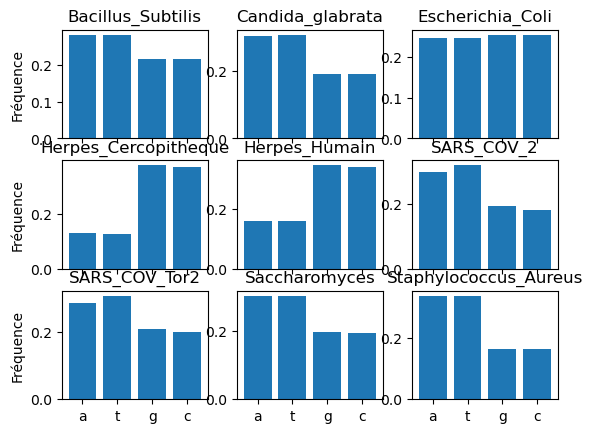

In [35]:
fig, axs = plt.subplots(3, 3)
count = 0
for i, j in itertools.product(range(3), range(3)):
    axs[i, j].bar(range(4), data[count])
    # Set title.
    axs[i, j].set_title(f"{liste_genomes[count]}")
    # Print atgc on x axis only for the bottom plots.
    if i == 2:
        axs[i, j].set_xticks(range(4), "atgc")
    else:
        axs[i, j].set_xticks(range(4), "")
    # y axis only on first col plots.
    if j ==0:
        axs[i, j].set_ylabel("Fréquence")
    count += 1

Centrer et standardiser les données.

In [36]:
data_norm = (data - data.mean()) / data.std()
print(data_norm)
print(f"mean = {data_norm.mean()} ; std = {data.std()}")

[[ 0.45644068  0.473668   -0.47215074 -0.45795794]
 [ 0.79881811  0.83910066 -0.81832342 -0.81959535]
 [-0.05459748 -0.05879943  0.05259847  0.06079844]
 [-1.74504659 -1.76224255  1.79786928  1.70941986]
 [-1.30217213 -1.32006785  1.36080414  1.26143584]
 [ 0.70895261  1.01588965 -0.77345735 -0.95138491]
 [ 0.50288758  0.82199764 -0.60291075 -0.72197447]
 [ 0.76506127  0.77372011 -0.73435043 -0.80443095]
 [ 1.21335722  1.24216379 -1.22062363 -1.23489738]]
mean = 7.771561172376096e-16 ; std = 0.06972939842623904


Calculer la matrice de variance / covariance. Vérifiez sa taille. Quelle est la taille attendue ?

In [39]:
cov_mat = np.cov(data_norm.T)
print(cov_mat)
cov_mat.shape

[[ 1.02533983  1.07677201 -1.05815763 -1.04395421]
 [ 1.07677201  1.1466867  -1.11579019 -1.10766853]
 [-1.05815763 -1.11579019  1.09366595  1.08028186]
 [-1.04395421 -1.10766853  1.08028186  1.07134088]]


(4, 4)

Calculer les valeurs et vecteurs propres. Combien en trouvez-vous ?

In [ ]:
eigenvals, eigenvect = np.linalg.eig(cov_mat)
print(eigenvals)
print(eigenvect)

Trier les valeurs propres (par ordre décroissant) et trier de même les vecteurs propres.

In [ ]:
index = eigenvals.argsort()[::-1]
eigenvals = eigenvals[index]
eigenvect = eigenvect[:,index]
print(eigenvals)
print(eigenvect)

[4.32733278e+00 9.14710454e-03 7.27083599e-17 5.53479931e-04]
[[-0.48585173  0.64545794  0.5        -0.311981  ]
 [-0.51394435 -0.6291253   0.5         0.30010426]
 [ 0.5024685  -0.31431337  0.5        -0.6314527 ]
 [ 0.49732757  0.29798073  0.5         0.64332944]]


Projeter les données sur les 2 premiers vecteurs propres.

In [53]:
# Pourcentage de variance expliquée par chaque valeur propre / vecteur propre.
(eigenvals / sum(eigenvals)) * 100

array([9.97763313e+01, 2.10906944e-01, 1.27617172e-02, 1.67645378e-15])

In [54]:
eigenvect1 = eigenvect[:,0]
eigenvect2 = eigenvect[:,1]

In [ ]:
Faire un plot de ces 2 projections (avec légende pour chaque génome).

In [56]:
# Le produit matriciel de notre matrice de données par le vect propre 1 
# donne la projection pour chaque génome sur le vect propre 1.
# np.dot(data_norm, eigenvect1)
proj1 = np.dot(data_norm, eigenvect1)
proj1
proj2 = np.dot(data_norm, eigenvect2)
proj2

array([ 0.00855739,  0.00069041,  0.00333619, -0.07340298, -0.06184463,
       -0.22190917, -0.2181783 , -0.00184079,  0.01737709])

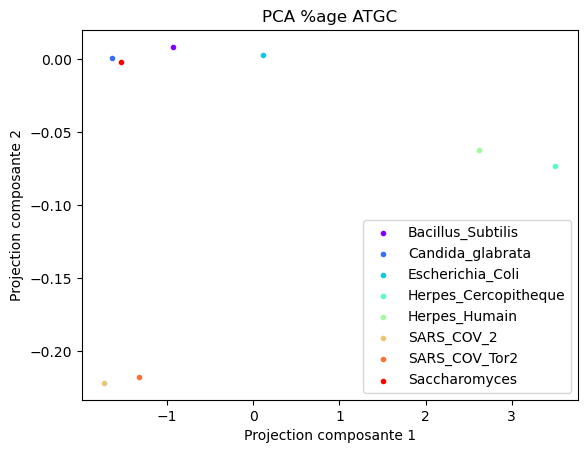

In [68]:
fig, ax = plt.subplots()

ax.set_xlabel("Projection composante 1")
ax.set_ylabel("Projection composante 2")
ax.set_title("PCA %age ATGC")
cols = plt.colormaps['rainbow'].resampled(8)
for x, y, num in zip(proj1, proj2, range(8)):
    ax.scatter(x, y, marker='.', color=cols(num), label=liste_genomes[num])
ax.legend()
